In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'true'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

In [ ]:
from IPython.display import clear_output

import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
from ultralytics import YOLO, settings
settings.update({'datasets_dir': os.path.abspath(os.path.join('..', '.data'))})

import sys
import importlib
importlib.reload(sys.modules['ultralytics'])
from ultralytics import YOLO

In [4]:
# import shutil
# FULL_PATH = '/Users/alex/Desktop/CS/ML/PCB-Detection/data/coco'
# TRAIN_PATH = FULL_PATH + '/train2017.txt'
# VAL_PATH = FULL_PATH + '/val2017.txt'
# DEST_PATH = '../.data/coco'
# os.mkdir(os.path.join(DEST_PATH, "images"))
# os.mkdir(os.path.join(DEST_PATH, "images", "train2017"))
# os.mkdir(os.path.join(DEST_PATH, "images", "val2017"))
# os.mkdir(os.path.join(DEST_PATH, "labels"))
# os.mkdir(os.path.join(DEST_PATH, "labels", "train2017"))
# os.mkdir(os.path.join(DEST_PATH, "labels", "val2017"))
# with open(VAL_PATH, "r") as f:
#     for img in np.random.choice(f.readlines(), 2000):
#         img: str = img.strip()
#         label = img.replace("images", "labels").replace(".jpg", ".txt")
#         if not os.path.exists(os.path.join(FULL_PATH, label)):
#             continue
#         shutil.copyfile(os.path.join(FULL_PATH, img), os.path.join(DEST_PATH, img))
#         shutil.copyfile(os.path.join(FULL_PATH, label), os.path.join(DEST_PATH, label))
#         with open(os.path.join(DEST_PATH, "test.txt"), "a") as g:
#             g.write(img + '\n')
# with open(TRAIN_PATH, "r") as f:
#     for i, img in enumerate(np.random.choice(f.readlines(), 10_000)):
#         img: str = img.strip()
#         label = img.replace("images", "labels").replace(".jpg", ".txt")
#         if not os.path.exists(os.path.join(FULL_PATH, label)):
#             continue
#         shutil.copyfile(os.path.join(FULL_PATH, img), os.path.join(DEST_PATH, img))
#         shutil.copyfile(os.path.join(FULL_PATH, label), os.path.join(DEST_PATH, label))
#         with open(os.path.join(DEST_PATH, "val.txt" if i < 2000 else "train.txt"), "a") as g:
#             g.write(img + '\n')

In [4]:
model = YOLO("../.data/yolo11n-seg.pt")
model.info()

YOLO11n-seg summary: 355 layers, 2,876,848 parameters, 0 gradients, 10.5 GFLOPs


(355, 2876848, 0, 10.5294976)

In [12]:
pytorch_size_kb = os.path.getsize("../.data/yolo11n-seg.pt") / 1e3
pytorch_size_kb

6182.636

In [6]:
results = model("../data/sample.jpg")


image 1/1 /Users/alex/Desktop/CS/ML/YADES/notebooks/../data/sample.jpg: 480x640 3 birds, 35.4ms
Speed: 1.4ms preprocess, 35.4ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


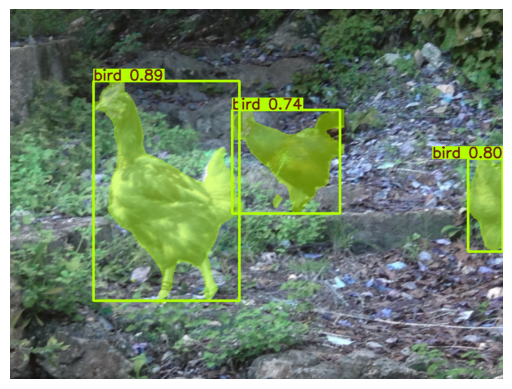

In [7]:
plt.imshow(results[0].plot())
plt.axis('off') # Optional: turn off axis labels
plt.show()

In [ ]:
metrics = model.val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='coco', save_dir='')
clear_output()

In [11]:
metrics.seg.map # map50-95

0.3305831262960633

## Quantization

### Dynamic

In [21]:
model.export(format="onnx", simplify=True, name="yolov11n.onnx", verbose=False, half=False)

Ultralytics 8.3.53 🚀 Python-3.10.12 torch-2.9.0 CPU (Apple M4 Max)
YOLO11n-seg summary (fused): 265 layers, 2,868,664 parameters, 0 gradients, 10.4 GFLOPs

PyTorch: starting from '../.data/yolo11n-seg.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 116, 8400), (1, 32, 160, 160)) (5.9 MB)

ONNX: starting export with onnx 1.17.0 opset 10...


W1101 02:15:34.099000 57677 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 10 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
Traceback (most recent call last):
  File "/Users/alex/Desktop/CS/ML/YADES/venv/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "/Users/alex/Desktop/CS/ML/YADES/venv/lib/python3.10/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/Users/alex/Desktop/CS/ML/YADES/venv/lib/python3.10/site-packages/onnxscript/version_conve

Applied 1 of general pattern rewrite rules.
ONNX: slimming with onnxslim 0.1.45...
ONNX: export success ✅ 1.6s, saved as '../.data/yolo11n-seg.onnx' (11.1 MB)

Export complete (1.9s)
Results saved to /Users/alex/Desktop/CS/ML/YADES/.data
Predict:         yolo predict task=segment model=../.data/yolo11n-seg.onnx imgsz=640  
Validate:        yolo val task=segment model=../.data/yolo11n-seg.onnx imgsz=640 data=/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app


'../.data/yolo11n-seg.onnx'

In [8]:
from onnxruntime.quantization import quantize_dynamic, QuantType

# Preprocess float32 model
!python -m onnxruntime.quantization.preprocess --input ../.data/yolo11n-seg.onnx --output ../data/yolov11-finetune/preprocessed.onnx

model_fp32 = '../data/yolov11-finetune/preprocessed.onnx'
model_int8 = '../data/yolov11-finetune/dynamic_quantized.onnx'

# Quantize 
quantize_dynamic(model_fp32, model_int8, weight_type=QuantType.QUInt8)

# model size as onnx
onnx_size_kb = os.path.getsize(model_int8) / 1e3
print("ONNX Model Size", onnx_size_kb / 1e3, "MB")
# note: pytorch dynamic quantization does not support convolutional layers, so we use onnxruntime for quantization

ONNX Model Size 3.198162 MB


In [12]:
metrics = YOLO(model_int8, task="segment").val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='dynamic-eval', save_dir='')
clear_output()
metrics.seg.map # map50-95

0.28425145476100605

In [23]:
import onnx
from onnxconverter_common import float16
onnx_model = onnx.load("../.data/yolo11n-seg.onnx")
model_fp16 = float16.convert_float_to_float16(onnx_model)
onnx.save(model_fp16, "../data/yolov11-finetune/yolov11_fp16.onnx")

In [26]:
metrics = YOLO("../data/yolov11-finetune/yolov11_fp16.onnx", task="segment").val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='half-eval', save_dir='', half=True)
clear_output()
metrics.seg.map # map50-95

0.3296568190330372

### Static

In [46]:
import onnx
from onnxruntime.quantization import CalibrationDataReader, quantize_static, QuantType, QuantFormat, CalibrationMethod
    
# Class for Callibration Data reading
class ImageCalibrationDataReader(CalibrationDataReader):
    def __init__(self):
        self.input_name = "images"
        self.batches_left = 1000
        self.files = os.listdir("../.data/coco/images/train2017")[:self.batches_left]

    def get_next(self):
        # method to iterate through the data set
        if len(self.files) == 0:
            return None
        image = np.moveaxis(cv2.resize(cv2.imread(os.path.join("../.data/coco/images/train2017", self.files[0])), (640, 640)), -1, 0)
        image = np.expand_dims(image, axis=0).astype(np.float32)
        self.files = self.files[1:]
        return {self.input_name: image}
    
# Exclude nodes:
ignore = []
for node in str(onnx.load(model_fp32).graph).split('\n'):
    if 'name: ' in node:
        name = node.split('name: ')[1].replace('"', '')
        if 'output' in name:
            continue
        for v in ['Split', 'Concat', 'Add', 'Flatten', 'Softmax', 'Sigmoid']:
            if v in name:
                ignore.append(name)
                break

# for weight_type in [QuantType.QUInt4, QuantType.QInt4, QuantType.QUInt8, QuantType.QInt8]:
for weight_type in [QuantType.QUInt4, QuantType.QUInt8, QuantType.QUInt16]:
    # for activation_type in [QuantType.QUInt4, QuantType.QInt4, QuantType.QUInt8, QuantType.QInt8, QuantType.QUInt16, QuantType.QInt16]:
    for activation_type in [QuantType.QUInt16]:
        for quant_format in [QuantFormat.QDQ, QuantFormat.QOperator]:
            # for calibrate_method in [CalibrationMethod.MinMax, CalibrationMethod.Entropy]:
            for calibrate_method in [CalibrationMethod.MinMax]:
                # Skip unsupported combinations
                if QuantType.QUInt16 in [weight_type, activation_type] and quant_format == QuantFormat.QOperator:
                    continue

                # Show settings
                print(f"Weight type: {weight_type}")
                print(f"Activation type: {activation_type}")
                print(f"Quant format: {quant_format}")
                print(f"Calibrate method: {calibrate_method}")

                # Create an instance of the ImageCalibrationDataReader
                calibration_data_reader = ImageCalibrationDataReader()

                # Quantize
                model_quantized = f'../data/yolov11-finetune/static_quantized_{weight_type}.onnx'
                quantize_static(
                    model_fp32, model_quantized,
                    weight_type=weight_type,
                    activation_type=activation_type,
                    calibration_data_reader=calibration_data_reader,
                    quant_format=quant_format,
                    calibrate_method=calibrate_method,
                    nodes_to_exclude=ignore,
                    per_channel=False,
                    reduce_range=True,
                )

                # model size as onnx
                onnx_size_kb = os.path.getsize(model_quantized) / 1e3
                print("ONNX Model Size", onnx_size_kb / 1e3, "MB")

Weight type: QUInt4
Activation type: QUInt16
Quant format: QDQ
Calibrate method: CalibrationMethod.MinMax


ONNX Model Size 1.792225 MB
Weight type: QUInt8
Activation type: QUInt16
Quant format: QDQ
Calibrate method: CalibrationMethod.MinMax


ONNX Model Size 3.2222020000000002 MB
Weight type: QUInt16
Activation type: QUInt16
Quant format: QDQ
Calibrate method: CalibrationMethod.MinMax


ONNX Model Size 6.082287 MB


In [47]:
metrics = YOLO("../data/yolov11-finetune/static_quantized_QUInt4.onnx", task="segment").val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='static-4bit-eval', save_dir='')
clear_output()
metrics.seg.map # map50-95

9.545165668370257e-08

In [48]:
metrics = YOLO("../data/yolov11-finetune/static_quantized_QUInt8.onnx", task="segment").val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='static-8bit-eval', save_dir='')
clear_output()
metrics.seg.map # map50-95

0.23374416167502013

In [49]:
metrics = YOLO("../data/yolov11-finetune/static_quantized_QUInt16.onnx", task="segment").val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='static-16bit-eval', save_dir='')
clear_output()
metrics.seg.map # map50-95

0.32310698611759814

### QAT

In [ ]:
import torch
torch.backends.quantized.engine = "qnnpack"

def enable_qat(trainer):
    m = trainer.model  # use trainer.model, not a separate wrapper
    m.eval()
    # Optional: fuse common blocks if your modules expose conv/bn
    # for mod in m.modules():
    #     if hasattr(mod, 'conv') and hasattr(mod, 'bn'):
    #         try:
    #             torch.ao.quantization.fuse_modules(mod, ['conv', 'bn'], inplace=True)
    #         except Exception:
    #             pass
    # Use a per-tensor weight qconfig to avoid per_channel_affine issues
    m.qconfig = torch.ao.quantization.get_default_qat_qconfig('qnnpack')
    m.train()
    torch.ao.quantization.prepare_qat(m, inplace=True)

def convert_qat(trainer):
    trainer.model.eval()
    int8_model = torch.ao.quantization.convert(trainer.model)
    torch.save(int8_model.state_dict(), f"../data/yolov11-finetune/qat_{trainer.epoch}.pt")

model = YOLO("../.data/yolo11n-seg.pt")
model.add_callback('on_pretrain_routine_start', enable_qat)
model.add_callback('on_train_epoch_end', convert_qat)
model.train(data="../.data/coco/data.yaml", epochs=10, project='../data/yolov11-finetune/', name='qat', save_dir='', save=False) # fraction=0.1
clear_output()

In [ ]:
import torch
torch.backends.quantized.engine = "qnnpack"

model = YOLO("../.data/yolo11n-seg.pt")
model.model.eval()
# for mod in model.model.modules():
#     if hasattr(mod, 'conv') and hasattr(mod, 'bn'):
#         try:
#             torch.ao.quantization.fuse_modules(mod, ['conv', 'bn'], inplace=True)
#         except Exception:
#             pass
model.model.qconfig = torch.ao.quantization.get_default_qat_qconfig('qnnpack') # type: ignore
model.model.train()
torch.ao.quantization.prepare_qat(model.model, inplace=True)
# torch.ao.quantization.convert(model.model.eval(), inplace=True)
state = torch.load(f"../data/yolov11-finetune/qat_10.pt")
for n, p in state.items():
    state[n] = p.dequantize()
model.model.load_state_dict(state, strict=False)

metrics = model.val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='qat-eval', save_dir='', device="mps")
clear_output()
metrics.seg.map # map50-95

0.14147799729340133

### QAT+Pruning

In [5]:
import torch.nn.utils.prune as prune

def yolo_prune(
    model,
    amount=0.3,
    include=[
        torch.nn.Conv2d,
        torch.ao.nn.quantized.modules.conv.Conv2d,
        torch.ao.nn.qat.modules.conv.Conv2d,
    ],
    n=1,
    structured: None | int = None,
    remove=True,
    recompute_masks=True,
):
    for name, module in model.named_modules():
        if not any(isinstance(module, e) for e in include):
            continue

        weight_mask = module.weight_mask if hasattr(module, "weight_mask") else None

        is_module_quantized = isinstance(
            module, torch.ao.nn.quantized.modules.conv.Conv2d
        )
        if is_module_quantized:
            scale, zero_point, dtype = (
                module.weight().q_scale(),
                module.weight().q_zero_point(),
                module.weight().dtype,
            )
            weight = module.weight().dequantize().contiguous()
            module = torch.nn.Conv2d(
                in_channels=module.in_channels,
                out_channels=module.out_channels,
                kernel_size=module.kernel_size,
                stride=module.stride,
                padding=module.padding,
                dilation=module.dilation,
                groups=module.groups,
                bias=False,
            )
            module.weight.data = weight

        param_name = "weight"
        p = None
        if recompute_masks:
            if structured is None:
                assert n == 1, "n must be 1 for unstructured pruning"
                p = prune.l1_unstructured(module, name=param_name, amount=amount)
                weight_mask = p.weight_mask
            else:
                if isinstance(structured, tuple) and isinstance(amount, tuple):
                    for a, dim in zip(amount, structured):
                        p = prune.ln_structured(
                            module, name=param_name, amount=a, n=n, dim=dim
                        )
                        weight_mask = p.weight_mask
                else:
                    p = prune.ln_structured(
                        module,
                        name=param_name,
                        amount=amount,
                        n=n,
                        dim=structured,
                    )
                    weight_mask = p.weight_mask
        elif weight_mask is not None:
            p = prune.custom_from_mask(module, name=param_name, mask=weight_mask)

        if remove:
            prune.remove(module, name=param_name)
            if p and not is_module_quantized:
                p.weight = torch.nn.Parameter(p.weight)
                module._forward_pre_hooks.clear()
            # if p:
            #     del p.weight_mask
            weight_mask = None

        if is_module_quantized:
            quantized_weights = torch.quantize_per_tensor(
                module.weight.data,
                scale=scale,
                zero_point=zero_point,
                dtype=dtype,
            )
            module = model.get_submodule(name)
            module.set_weight_bias(quantized_weights, None)
            # set hook on forward to apply mask
            module._forward_pre_hooks.clear()
            if weight_mask is not None:

                def apply_mask(module, input):
                    module.set_weight_bias(module.weight() * weight_mask, None)
                    return input

                module.register_forward_pre_hook(apply_mask)

                # save the mask
                module.weight_mask = weight_mask

In [ ]:
# TODO: make repo private, run LLM Q&A eval

In [63]:
model = YOLO("../.data/yolo11n-seg.pt")
yolo_prune(model.model, amount=0.3, structured=0, remove=False, recompute_masks=True)
yolo_prune(model.model, amount=0.3, structured=0, remove=True, recompute_masks=False)
metrics = model.val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='prune-0.3-eval', save_dir='')
clear_output()
torch.save(model.half().state_dict(), '../data/yolov11-finetune/prune-0.3.pt')
import gzip
with open('../data/yolov11-finetune/prune-0.3.pt', "rb") as f:
    data = f.read()
with gzip.open('../data/yolov11-finetune/prune-0.3.pt.zip', "wb") as f:
    f.write(data)  # type: ignore
print(os.path.getsize('../data/yolov11-finetune/prune-0.3.pt.zip') / 1e3)
metrics.seg.map # map50-95

3804.341


0.0

In [64]:
model = YOLO("../.data/yolo11n-seg.pt")
yolo_prune(model.model, amount=0.5, structured=0, remove=False, recompute_masks=True)
yolo_prune(model.model, amount=0.5, structured=0, remove=True, recompute_masks=False)
metrics = model.val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='prune-0.5-eval', save_dir='')
clear_output()
torch.save(model.half().state_dict(), '../data/yolov11-finetune/prune-0.5.pt')
import gzip
with open('../data/yolov11-finetune/prune-0.5.pt', "rb") as f:
    data = f.read()
with gzip.open('../data/yolov11-finetune/prune-0.5.pt.zip', "wb") as f:
    f.write(data)  # type: ignore
print(os.path.getsize('../data/yolov11-finetune/prune-0.5.pt.zip') / 1e3)
metrics.seg.map # map50-95

2749.12


0.0

In [65]:
model = YOLO("../.data/yolo11n-seg.pt")
yolo_prune(model.model, amount=0.7, structured=0, remove=False, recompute_masks=True)
yolo_prune(model.model, amount=0.7, structured=0, remove=True, recompute_masks=False)
metrics = model.val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='prune-0.7-eval', save_dir='')
clear_output()
torch.save(model.half().state_dict(), '../data/yolov11-finetune/prune-0.7.pt')
import gzip
with open('../data/yolov11-finetune/prune-0.7.pt', "rb") as f:
    data = f.read()
with gzip.open('../data/yolov11-finetune/prune-0.7.pt.zip', "wb") as f:
    f.write(data)  # type: ignore
print(os.path.getsize('../data/yolov11-finetune/prune-0.7.pt.zip') / 1e3)
metrics.seg.map # map50-95

1690.648


0.0

In [66]:
model = YOLO("../.data/yolo11n-seg.pt")
yolo_prune(model.model, amount=0.9, structured=0, remove=False, recompute_masks=True)
yolo_prune(model.model, amount=0.9, structured=0, remove=True, recompute_masks=False)
metrics = model.val(data="../.data/coco/data.yaml", split="test", project='../data/yolov11-finetune/', name='prune-0.9-eval', save_dir='')
clear_output()
torch.save(model.half().state_dict(), '../data/yolov11-finetune/prune-0.9.pt')
import gzip
with open('../data/yolov11-finetune/prune-0.9.pt', "rb") as f:
    data = f.read()
with gzip.open('../data/yolov11-finetune/prune-0.9.pt.zip', "wb") as f:
    f.write(data)  # type: ignore
print(os.path.getsize('../data/yolov11-finetune/prune-0.9.pt.zip') / 1e3)
metrics.seg.map # map50-95

621.373


0.0

In [ ]:
# Prereq (support weight moving averages with pruning mask): 
# Patch venv/lib/python3.10/site-packages/ultralytics/utils/torch_utils.py ModelEMA.update to make line 531 (v += (1 - d) * msd[k].detach()) into
# if k in msd:
#     w = msd[k]
# else:
#     w = msd[k + '_orig'] * msd[k + '_mask']
# v += (1 - d) * w.detach()

epoch = 0
amounts = [0.1, 0.2, 0.3, 0.3, 0.3, 0.4, 0.5, 0.5, 0.5, 0.6, 0.7, 0.7, 0.7, 0.8, 0.9, 0.9, 0.9]

def prune_recompute(trainer):
    yolo_prune(trainer.model, amount=amounts[epoch], structured=0, remove=False, recompute_masks=True)

def prune_maintain(trainer):
    yolo_prune(trainer.model, amount=amounts[epoch], structured=0, remove=False, recompute_masks=False)

def prune_remove(trainer):
    global epoch
    
    m = trainer.model
    m.eval()
    yolo_prune(m, amount=amounts[epoch], structured=0, remove=True, recompute_masks=False)
    int8_model = torch.ao.quantization.convert(m)
    torch.save(int8_model.state_dict(), f"../data/yolov11-finetune/qatprune_{epoch}_{amounts[epoch]}.pt")

    epoch += 1

model = YOLO("../.data/yolo11n-seg.pt")
model.add_callback('on_pretrain_routine_start', enable_qat)
model.add_callback('on_train_epoch_start', prune_recompute)
model.add_callback('on_train_batch_end', prune_maintain)
model.add_callback('on_train_epoch_end', prune_remove)
model.train(data="../.data/coco/data.yaml", epochs=len(amounts), project='../data/yolov11-finetune/', name='qatprune', save_dir='', save=False) # fraction=0.1